# **Practical - 2**

### **Aim:** To handle missing, inconsistent, and noisy data using Pandas and NumPy techniques.

**Problem Definition:** Students will load datasets containing missing and inconsistent values, identify data quality issues, apply appropriate cleaning strategies such as removal, imputation, replacement, and grouping, and save cleaned datasets for further analysis.

### Objectives
- To identify missing and inconsistent data
- To apply appropriate data cleaning techniques
- To analyze the impact of cleaning on datasets

**Dataset:** employees.csv (attached) | **Tools:** Python, Pandas, NumPy

###1 : Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

###2 : Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd

###3 : Load the Dataset

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Pract_2/employees.csv')
print(data.head())
data.info()

  First Name  Gender Start Date Last Login Time  Salary  Bonus %  \
0    Douglas    Male   8/6/1993        12:42 PM   97308    6.945   
1     Thomas    Male  3/31/1996         6:53 AM   61933    4.170   
2      Maria  Female  4/23/1993        11:17 AM  130590   11.858   
3      Jerry    Male   3/4/2005         1:00 PM  138705    9.340   
4      Larry    Male  1/24/1998         4:47 PM  101004    1.389   

  Senior Management             Team  
0              True        Marketing  
1              True              NaN  
2             False          Finance  
3              True          Finance  
4              True  Client Services  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   First Name         933 non-null    object 
 1   Gender             855 non-null    object 
 2   Start Date         1000 non-null   object 
 3   Last Lo

### Preview: First 5 Rows

In [ ]:
data.head()

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,Douglas,Male,8/6/1993,12:42 PM,97308,6.945,True,Marketing
1,Thomas,Male,3/31/1996,6:53 AM,61933,4.170,True,NaN
2,Maria,Female,4/23/1993,11:17 AM,130590,11.858,False,Finance
3,Jerry,Male,3/4/2005,1:00 PM,138705,9.340,True,Finance
4,Larry,Male,1/24/1998,4:47 PM,101004,1.389,True,Client Services


### Preview: Last 5 Rows

In [ ]:
data.tail()

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
995,Henry,NaN,11/23/2014,6:09 AM,132483,16.655,False,Distribution
996,Phillip,Male,1/31/1984,6:30 AM,42392,19.675,False,Finance
997,Russell,Male,5/20/2013,12:39 PM,96914,1.421,False,Product
998,Larry,Male,4/20/2013,4:45 PM,60500,11.985,False,Business Development
999,Albert,Male,5/15/2012,6:24 PM,129949,10.169,True,Sales


###Identifying Missing Value :

In [ ]:
data.isnull().sum()

,0
First Name,67
Gender,145
Start Date,0
Last Login Time,0
Salary,0
Bonus %,0
Senior Management,67
Team,43


###Finding the rows to see where the entries are null :

In [ ]:
null_rows=data[data.isna().any(axis=1)]
null_rows

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
1,Thomas,Male,3/31/1996,6:53 AM,61933,4.170,True,NaN
7,NaN,Female,7/20/2015,10:43 AM,45906,11.598,NaN,Finance
10,Louise,Female,8/12/1980,9:01 AM,63241,15.132,True,NaN
20,Lois,NaN,4/22/1995,7:18 PM,64714,4.934,True,Legal
22,Joshua,NaN,3/8/2012,1:58 AM,90816,18.816,True,Client Services
...,...,...,...,...,...,...,...,...
961,Antonio,NaN,6/18/1989,9:37 PM,103050,3.050,False,Legal
972,Victor,NaN,7/28/2006,2:49 PM,76381,11.159,True,Sales
985,Stephen,NaN,7/10/1983,8:10 PM,85668,1.909,False,Legal
989,Justin,NaN,2/10/1991,4:58 PM,38344,3.794,False,Legal


###4 : Removing Rows with Missing Values

In [ ]:
data_any=data.dropna()
# data_any=data.dropna(how='all') wont work because it removes those rows where all the entry's for every coloumn value if null
print('Removed All Null Data in every Row')
data_any.info()

Removed All Null Data in every Row
<class 'pandas.core.frame.DataFrame'>
Index: 764 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   First Name         764 non-null    object 
 1   Gender             764 non-null    object 
 2   Start Date         764 non-null    object 
 3   Last Login Time    764 non-null    object 
 4   Salary             764 non-null    int64  
 5   Bonus %            764 non-null    float64
 6   Senior Management  764 non-null    object 
 7   Team               764 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 53.7+ KB


### Before vs After Comparison

In [ ]:
data.info()
print('\n\nComparision: We reduced our +8.9kb of memory usage')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   First Name         933 non-null    object 
 1   Gender             855 non-null    object 
 2   Start Date         1000 non-null   object 
 3   Last Login Time    1000 non-null   object 
 4   Salary             1000 non-null   int64  
 5   Bonus %            1000 non-null   float64
 6   Senior Management  933 non-null    object 
 7   Team               957 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 62.6+ KB


Comparision: We reduced our +8.9kb of memory usage


###5 : Imputing Missing Values

In [ ]:
data['Team']=data['Team'].fillna('Unknown Team')

# Forward fill and backward fill
# Forward fill (ffill): replace NaN with previous row value
# Backward fill (bfill): replace NaN with next row value

# Forward fill
data['Gender'] = data['Gender'].fillna(method='ffill')

# Backward fill
# data['Bonus %'] = data['Bonus %'].fillna(method='bfill')

data['Salary']=data['Salary'].fillna(data['Salary'].mean())
data

/tmp/ipython-input-3249154997.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['Gender'] = data['Gender'].fillna(method='ffill')


,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,Douglas,Male,8/6/1993,12:42 PM,97308,6.945,True,Marketing
1,Thomas,Male,3/31/1996,6:53 AM,61933,4.170,True,Unknown Team
2,Maria,Female,4/23/1993,11:17 AM,130590,11.858,False,Finance
3,Jerry,Male,3/4/2005,1:00 PM,138705,9.340,True,Finance
4,Larry,Male,1/24/1998,4:47 PM,101004,1.389,True,Client Services
...,...,...,...,...,...,...,...,...
995,Henry,Male,11/23/2014,6:09 AM,132483,16.655,False,Distribution
996,Phillip,Male,1/31/1984,6:30 AM,42392,19.675,False,Finance
997,Russell,Male,5/20/2013,12:39 PM,96914,1.421,False,Product
998,Larry,Male,4/20/2013,4:45 PM,60500,11.985,False,Business Development


###6 : Handling Inconsistent Data — Replacing Values

In [ ]:
print('Firing all Business Development Team ')
data['Team']=data['Team'].replace(
  {'Business Development':'Fired',
  'Sales':'AI'}
  )
data


Firing all Business Development Team 


,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,Douglas,Male,8/6/1993,12:42 PM,97308,6.945,True,Marketing
1,Thomas,Male,3/31/1996,6:53 AM,61933,4.170,True,Unknown Team
2,Maria,Female,4/23/1993,11:17 AM,130590,11.858,False,Finance
3,Jerry,Male,3/4/2005,1:00 PM,138705,9.340,True,Finance
4,Larry,Male,1/24/1998,4:47 PM,101004,1.389,True,Client Services
...,...,...,...,...,...,...,...,...
995,Henry,Male,11/23/2014,6:09 AM,132483,16.655,False,Distribution
996,Phillip,Male,1/31/1984,6:30 AM,42392,19.675,False,Finance
997,Russell,Male,5/20/2013,12:39 PM,96914,1.421,False,Product
998,Larry,Male,4/20/2013,4:45 PM,60500,11.985,False,Fired


###7 : Groupby Analysis — Bonus by Employee

In [ ]:
data.groupby('First Name')['Bonus %'].agg(['mean','count','max','min'])

,mean,count,max,min
First Name,,,,
Aaron,11.678250,4,18.424,5.097
Adam,9.591250,4,15.120,3.491
Alan,10.418000,3,17.578,3.592
Albert,12.597500,6,19.717,5.850
Alice,8.772875,8,15.397,2.378
...,...,...,...,...
Walter,11.891400,5,18.099,5.461
Wanda,13.413500,2,19.695,7.132
Wayne,13.068750,4,18.396,2.728


### Current State of Dataset

In [ ]:
data

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,Douglas,Male,8/6/1993,12:42 PM,97308,6.945,True,Marketing
1,Thomas,Male,3/31/1996,6:53 AM,61933,4.170,True,Unknown Team
2,Maria,Female,4/23/1993,11:17 AM,130590,11.858,False,Finance
3,Jerry,Male,3/4/2005,1:00 PM,138705,9.340,True,Finance
4,Larry,Male,1/24/1998,4:47 PM,101004,1.389,True,Client Services
...,...,...,...,...,...,...,...,...
995,Henry,Male,11/23/2014,6:09 AM,132483,16.655,False,Distribution
996,Phillip,Male,1/31/1984,6:30 AM,42392,19.675,False,Finance
997,Russell,Male,5/20/2013,12:39 PM,96914,1.421,False,Product
998,Larry,Male,4/20/2013,4:45 PM,60500,11.985,False,Fired


###8 : Groupby Analysis — Salary by Team


In [ ]:
print('IMPORTANT DATA')
data.groupby('Team')['Salary'].agg(['mean','max','min','count'])

IMPORTANT DATA


,mean,max,min,count
Team,,,,
AI,92173.436170,149654,35802,94
Client Services,88224.424528,147183,35095,106
Distribution,88500.466667,149105,35575,90
Engineering,94269.195652,147362,36946,92
Finance,92219.480392,149908,35381,102
Fired,91866.316832,147417,36844,101
Human Resources,90944.527473,149903,35203,91
Legal,89303.613636,148985,35061,88
Marketing,90435.591837,149456,36643,98


###9 : Creating Summary DataFrame


In [ ]:
imp_data = {
    "Team": ["AI", "Client Services", "Distribution", "Engineering", "Finance",
             "Fired", "Human Resources", "Legal", "Marketing", "Product", "Unknown Team"],
    "Mean": [92173.43, 88224.42, 88500.47, 94269.20, 92219.48,
             91866.32, 90944.53, 89303.61, 90435.59, 88665.51, 90763.14],
    "Max": [149654, 147183, 149105, 147362, 149908,
            147417, 149903, 148985, 149456, 149684, 148291],
    "Min": [35802, 35095, 35575, 36946, 35381,
            36844, 35203, 35061, 36643, 35013, 37919],
    "Count": [94, 106, 90, 92, 102, 101, 91, 88, 98, 95, 43]
}

data = pd.DataFrame(imp_data)

###10 : Visualization — Average Salary by Team

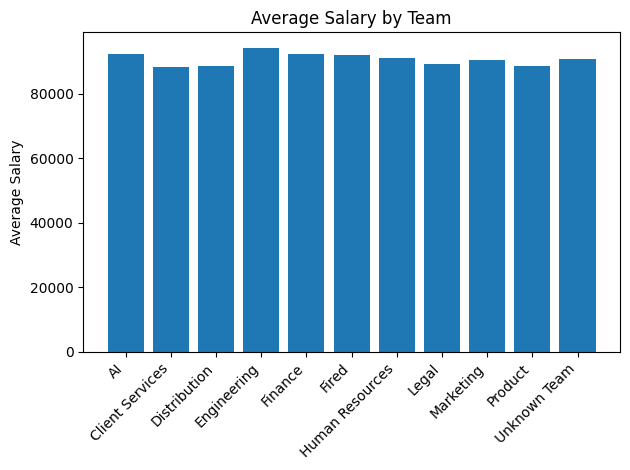

In [ ]:
# average salary by team :
import matplotlib.pyplot as plt

plt.figure()
plt.bar(data["Team"], data["Mean"])
plt.xticks(rotation=45, ha="right")
plt.title("Average Salary by Team")
plt.ylabel("Average Salary")
plt.tight_layout()
plt.show()


### Visualization — Salary Range (Max vs Min) by Team

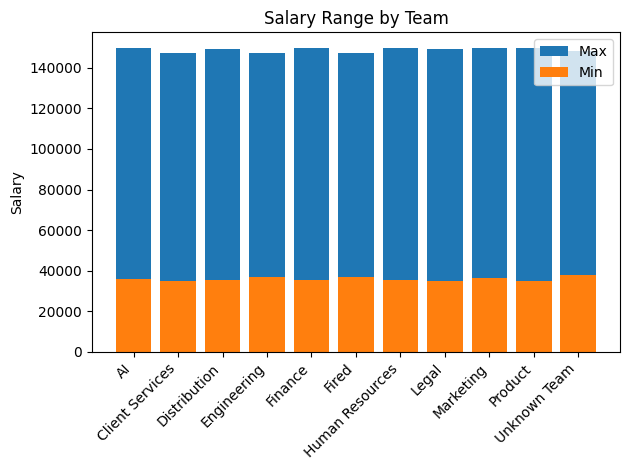

In [ ]:
plt.figure()
plt.bar(data["Team"], data["Max"], label="Max")
plt.bar(data["Team"], data["Min"], label="Min")
plt.xticks(rotation=45, ha="right")
plt.title("Salary Range by Team")
plt.ylabel("Salary")
plt.legend()
plt.tight_layout()
plt.show()

###Cleaning the datasets

In [ ]:

print('This shows we aleady cleaned up our data')
data.isnull().sum()

This shows we aleady cleaned up our data


,0
Team,0
Mean,0
Max,0
Min,0
Count,0


###11 : Save the Cleaned Dataset

In [ ]:
data.to_csv('cleaned_weather.csv')

### Key Questions
- When should data be dropped vs. imputed?

   Drop data when very few rows are missing and losing them won't affect results; impute (fill) data when too many rows are missing and dropping them would lose important information.
   
- How does cleaning affect analytical results?

  Dirty data (with missing or wrong values) gives incorrect averages, totals, and patterns — after cleaning, results become accurate, reliable, and trustworthy for decision-making.

### Assignment Tasks
- Clean a dataset with missing and inconsistent values
- Perform groupby aggregation
- Save the cleaned dataset and write a short reflection

In [ ]:
# TASK 1: Clean a dataset with missing and inconsistent values
data = pd.DataFrame({
    'Name':   ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace'],
    'Gender': ['Female', None, 'Male', 'Male', None, 'Male', 'Female'],
    'Team':   ['Sales', 'HR', None, 'Business Development', 'HR', None, 'Sales'],
    'Salary': [50000, 60000, None, 55000, None, 70000, 48000],
    'Bonus%': [5.0, None, 4.5, None, 6.0, 3.5, None]
})

print("=== BEFORE CLEANING ===")
print(data)
print("\nMissing Values:\n", data.isnull().sum())

# Fill missing Team with 'Unknown Team'
data['Team'] = data['Team'].fillna('Unknown Team')

# Forward fill Gender
data['Gender'] = data['Gender'].fillna(method='ffill')

# Fill Salary with mean
data['Salary'] = data['Salary'].fillna(data['Salary'].mean())

# Fill Bonus% with mean
data['Bonus%'] = data['Bonus%'].fillna(data['Bonus%'].mean())

# Fix inconsistent values
data['Team'] = data['Team'].replace({
    'Business Development': 'BD',
    'Sales': 'AI'
})

print("\n=== AFTER CLEANING ===")
print(data)
print("\nMissing Values After Cleaning:\n", data.isnull().sum())

=== BEFORE CLEANING ===
      Name  Gender                  Team   Salary  Bonus%
0    Alice  Female                 Sales  50000.0     5.0
1      Bob    None                    HR  60000.0     NaN
2  Charlie    Male                  None      NaN     4.5
3    David    Male  Business Development  55000.0     NaN
4      Eve    None                    HR      NaN     6.0
5    Frank    Male                  None  70000.0     3.5
6    Grace  Female                 Sales  48000.0     NaN

Missing Values:
 Name      0
Gender    2
Team      2
Salary    2
Bonus%    3
dtype: int64

=== AFTER CLEANING ===
      Name  Gender          Team   Salary  Bonus%
0    Alice  Female            AI  50000.0    5.00
1      Bob  Female            HR  60000.0    4.75
2  Charlie    Male  Unknown Team  56600.0    4.50
3    David    Male            BD  55000.0    4.75
4      Eve    Male            HR  56600.0    6.00
5    Frank    Male  Unknown Team  70000.0    3.50
6    Grace  Female            AI  48000.0    4.

/tmp/ipython-input-2328525438.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['Gender'] = data['Gender'].fillna(method='ffill')


In [ ]:
# TASK 2: Perform Groupby Aggregation
print("\n=== GROUPBY: Average Salary by Team ===")
team_salary = data.groupby('Team')['Salary'].agg(['mean', 'max', 'min', 'count'])
print(team_salary)

print("\n=== GROUPBY: Average Bonus% by Gender ===")
gender_bonus = data.groupby('Gender')['Bonus%'].agg(['mean', 'max', 'min'])
print(gender_bonus)


=== GROUPBY: Average Salary by Team ===
                 mean      max      min  count
Team                                          
AI            49000.0  50000.0  48000.0      2
BD            55000.0  55000.0  55000.0      1
HR            58300.0  60000.0  56600.0      2
Unknown Team  63300.0  70000.0  56600.0      2

=== GROUPBY: Average Bonus% by Gender ===
            mean  max   min
Gender                     
Female  4.833333  5.0  4.75
Male    4.687500  6.0  3.50


In [ ]:
# TASK 3: Save the Cleaned Dataset
data.to_csv('cleaned_employees.csv', index=False)
print("\n✅ Cleaned dataset saved as 'cleaned_employees.csv'")

# Verify saved file
saved = pd.read_csv('cleaned_employees.csv')
print("\n=== SAVED FILE PREVIEW ===")
print(saved)


✅ Cleaned dataset saved as 'cleaned_employees.csv'

=== SAVED FILE PREVIEW ===
      Name  Gender          Team   Salary  Bonus%
0    Alice  Female            AI  50000.0    5.00
1      Bob  Female            HR  60000.0    4.75
2  Charlie    Male  Unknown Team  56600.0    4.50
3    David    Male            BD  55000.0    4.75
4      Eve    Male            HR  56600.0    6.00
5    Frank    Male  Unknown Team  70000.0    3.50
6    Grace  Female            AI  48000.0    4.75


## Conclusion:
In this practical, we learned how to detect and fix missing, inconsistent, and noisy data using Pandas techniques like fillna(), dropna(), and replace(). Clean data leads to accurate and reliable analysis, making data cleaning an essential first step before any data processing or decision-making.